# 2.2 - Amostras de Tamanho Variável

## População e Amostras

Na estatística, a *população* e a *amostra* de dados são conceitos fundamentais, mas que podem ser facilmente confundidos. Compreendê-los é crítico para realizar abordagens em que se faz necessário a distinção desses termos para a interpretação de dados.

A população refere-se ao conjunto de *todas* as observações referentes a um conjunto de dados. Ou seja, se uma tabela possui informações sobre $N$ observações, a totalidade desses registros compõe a população. Já a amostra é um subconjunto da população que é explorado para análise, como uma determinada fração de $N$. 

### Qual devo analisar?

"Os dados da população são usados quando sua pergunta de pesquisa exige isso, ou quando você tem acesso a dados de todos os membros da população. Geralmente, é fácil coletar dados de toda a população apenas quando ela é pequena, acessível e cooperativa.

Exemplo:

- Um gerente de marketing de uma pequena padaria local quer entender as preferências dos clientes. Eles coletam dados sobre a compra de pães de cada cliente durante um mês. Como a base de clientes é limitada e acessível, eles analisam toda a população para identificar tendências.

Quando usar uma Amostra:

- Quando sua população é grande, geograficamente espalhada ou difícil de contatar, é necessário usar uma amostra. Com a análise estatística, você pode usar dados da amostra para fazer estimativas ou testar hipóteses sobre os dados da população." [1]

### Validando amostras

## Pondo em prática

Vamos utilizar um banco de dados sobre materiais suprecondutores [3], mais especificamente a variável aleatória temperatura crítica de cada um deles, a qual é medida em Kelvin. Essa medida marca a transição de um material para a fase de supercondutividade, sendo que é abaixo dessa temperatura que o material passa a atuar como um supercondutor [4].

Bom, vamos dar uma breve olhada em nossos dados.

In [2]:
import pandas as pd

df = pd.read_csv("superconductivity.csv")
temp_criticas = df["critical_temp"]

temp_criticas.describe()


count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

21 mil observações é um número robusto para a nossa análise, e podemos também verificar que se tratam de dados quantitativos contínuos - `float` - bem como não há dados faltando. Além disso, podemos notar que 50% dos dados estão abaixo de 20, com um mínimo de quase 0 K, e a outra metade está acima dessa medida, com um máximo de 185 K. Ademais, é notável a média de temperatura crítica de cerca de 34 K e um desvio padrão aproximadamente semelhante.

### Buscando a proporção da amostra

Vamos supor um cenário de necessidade por otimização dos processos computacionais, mas que ainda precisemos de estatísticas desses dados. Como há muitas observações, não necessariamente precisamos de toda a população, pois bastará uma amostra dela. Mas qual deve ser o tamanho da amostra? 

Se nos basearmos apenas em algumas dezenas de observações aleatórias, a probabilidade das estatísticas (média, mediana, desvio padrão médio, etc...) variarem drasticamente de amostra para amostra seriam altíssimas. Dessa forma, esses dados apresentariam alta variância ($\text{Var}(X)$), o que ocasiona um alto desvio padrão ($\sigma$) entre as amostras. Esses termos são definidos *para a população* como

$$
\tag{1.1}
\text{Var}(X) = \frac{1}{N} \sum_{i=1}^{N} (X_i - \mu)^2
$$

$$
\tag{1.2}
\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N} (X_i - \mu)^2}
$$

Em que $\mu$ indica a média dos valores da população $X$ e $\sigma$ é a raíz quadrada positiva da variância. Por conta de relação matemática, a variância também pode ser escrita como $\sigma^2$, assim como pode ser inferido que minimizar a variância implica em minimizar desvio padrão.

É importante pontuar a diferença de notação e de cálculo dessas métricas *para amostras*! 

$$
\tag{1.3}
s^2 = \frac{1}{n}\sum_{i=1}^{n} (X_i - \bar{X})^2
$$

$$
\tag{1.4}
s = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (X_i - \bar{X})^2}
$$

Com $\bar{X} representando a média amostral, $n$, o número de observações da amostra e o termo $\frac{1}{n} sendo alterado para $\frac{1}{n -1}$ pela *correção de Bessel* [5].

Logo, é muito arriscado elencar uma amostra tão pequena para representar a população. Entretanto, se designarmos uma amostra muito grande, o ganho de otimização não será tão expressivo como desejado. Assim, como buscar o equilíbrio entre esses termos?

Iremos definir uma porcentagem da população que será aleatoriamente selecionada (com reposição) para compor 50 amostras. De cada uma delas, será calculada a média, e então será registrado o desvio padrão desse conjunto de médias correspondente a cada tamanho de amostra.  
Um conjunto de médias com alto desvio padrão signifca que a média dos conjuntos varia demais a depender das amostras selecionadas, o que nos faz concluir que usar essa porcentagem da população para compor uma amostra é pouco confiável para representar a população.

Portanto, devemos buscar reduzir essa variância da amostra e otimizar o sistema.

In [7]:
import numpy as np
import statistics as st

# definindo variáveis para todo o programa e 
#   a semente aleatória p/ garantir reprodutibilidade dos resultados
NUMERO_AMOSTRAS: int = 50
n_observacoes: int = len(temp_criticas)
amostragem: list = list(range(5, 90)) # [5, 6, 7, ..., 90]
np.random.seed(42)

def amostragem_aleatoria(
    dados: pd.DataFrame | pd.Series,
    


) -> dict:
    # Definindo o dicionário que servirá de base para montar o DataFrame
    stdev_amostras: dict = {
        "Amostragem (% pop.)": amostragem,
        "Desvio padrão das médias": [],
        "Diferença Média populacional e Média agregada das amostras": [],
        "SEM": []
    }

    # For loop para cada % da população
    for p in amostragem:
        tamanho_amostra: int = int(n_observacoes * p / 100)
        medias: list = []

        # For loop para as 50 amostras com a % correspondente
        for _ in range(NUMERO_AMOSTRAS):
            amostra = temp_criticas.sample(
                n=tamanho_amostra,
                replace=True
                )

            medias.append(amostra.mean())

        # Salvando dados das amostras de cada % no dicionário
        stdev_amostras["Desvio padrão das médias"].append(st.stdev(medias))
        stdev_amostras["Diferença Média populacional e Média agregada das amostras"].append(temp_criticas.mean() - np.mean(medias))
        
        sem = st.stdev(medias) / NUMERO_AMOSTRAS ** (1/2)
        stdev_amostras["SEM"].append(sem)

In [ ]:
import numpy as np
import statistics as st

def analise_amostragem_aleatoria(
    dados: pd.DataFrame | pd.Series,
    amostragem_pctg: np.ndarray[int | float],
    qntd_amostras: int,
    semente_aleatoria: int = 0
) -> dict:

    # Definindo o dicionário que servirá de base para montar o DataFrame
    stdev_amostras: dict = {
        "Amostragem (% pop.)": amostragem,
        "Desvio padrão das médias": [],
        "Diferença Média populacional e Média agregada das amostras": [],
        "SEM": []
    }

    np.random.seed(semente_aleatoria)
    n_observacoes: int = len(dados)

    # For loop para cada % da população
    for pctg in amostragem_pctg:
        medias: list = []
        tamanho_amostra: int = int(n_observacoes * pctg / 100)

        # For loop para as 50 amostras com a % correspondente
        for _ in range(qntd_amostras):
            
            amostra = dados.sample(
                n=tamanho_amostra,
                replace=True
                )

            medias.append(amostra.mean())

        # Salvando dados das amostras de cada % no dicionário
        stdev_amostras["Desvio padrão das médias"].append(st.stdev(medias))
        stdev_amostras["μ - x̄"].append(dados.mean() - np.mean(medias))
        
        sem = st.stdev(medias) / qntd_amostras ** (1/2)
        stdev_amostras["SEM"].append(sem)
    
    return stdev_amostras

In [ ]:
# definindo variáveis para todo o programa e 
#   a semente aleatória p/ garantir reprodutibilidade dos resultados
NUMERO_AMOSTRAS: int = 50
amostragem: list = list(range(5, 90)) # [5, 6, 7, ..., 90]

analise_amostragem_aleatoria(
    temp_criticas,
    amostragem,
    NUMERO_AMOSTRAS,
    semente_aleatoria=42
    )

In [8]:
# DataFrame com Standard Deviations (dfsa)
dfsa = pd.DataFrame.from_dict(stdev_amostras)

# Filtrando apenas valores desejados
logica = dfsa["Amostragem (% pop.)"].isin([10, 30, 50, 70, 90])
df_filtrado = dfsa.loc[logica]
df_filtrado.style.hide(axis='index')

Amostragem (% pop.),Desvio padrão das médias,Diferença Média populacional e Média agregada das amostras,SEM
10,0.888035,-0.064913,0.125587
30,0.427238,0.006985,0.060421
50,0.358143,0.017096,0.050649
70,0.272794,-0.002948,0.038579


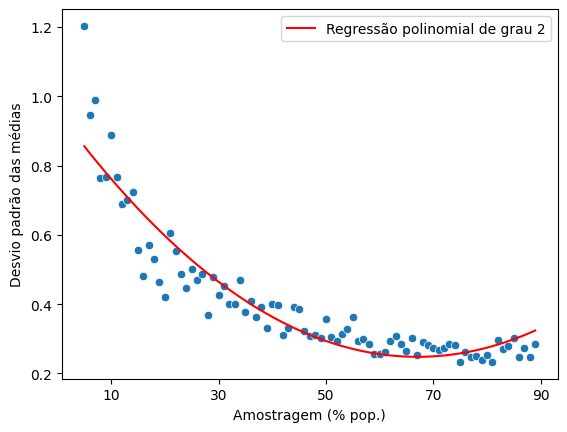

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

GRAU_POLINOMIO = 2

x = dfsa[["Amostragem (% pop.)"]]
y = dfsa["Desvio padrão das médias"]

pipeline = make_pipeline(
    PolynomialFeatures(GRAU_POLINOMIO, include_bias=False),
    LinearRegression(),
)

pipeline.fit(x, y)

y_previsto = pipeline.predict(x)

sns.scatterplot(
    dfsa,
    x="Amostragem (% pop.)",
    y="Desvio padrão das médias"
)
plt.xticks([10, 30, 50, 70, 90])

sns.lineplot(x=x.values.ravel(), y=y_previsto, color="red", label="Regressão polinomial de grau 2");
# print()

## Conclusão

The standard error specifically for the sample mean. Measures how far the sample mean is likely to be from the true population mean.

## Referências

[1] https://www.geeksforgeeks.org/maths/population-and-sample-statistics/

[2] https://statisticsbyjim.com/hypothesis-testing/standard-error-mean/

[3] https://archive.ics.uci.edu/dataset/464/superconductivty+data

[4] Bardeen, J., Cooper, L. N., & Schrieffer, J. R. (1957). Theory of Superconductivity. Physical Review, 108(5), 1175–1204 https://journals.aps.org/pr/pdf/10.1103/PhysRev.108.1175

[5] https://www.statisticshowto.com/bessels-correction/